### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP2: Principal components regression in genetics

The goal of this TP session is to use genetic markers to predict the geographical origin of a set of indians from South, Central, and North America. We propose to build two regression linear models to predict the latitude and longitude of an individual based on its genetic markers. Because the number of markers (p = 5709) is larger than the number of samples (N = 494), the predictors of the regression model will be the outputs of a principal component analysis (PCA) performed on the genetic markers. A genetic marker is encoded 1 if the individual has a mutation, 0 elsewhere.

## ▶️ Exercise 1: Data visualization (1 point)

NB: To do this exercise you will have to install packages `geopandas` and `geodatasets`.

Download dataset `NAm2.txt` from [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP2/NAm2.txt). Each row of the dataset corresponds to an individual and the columns have explicit names. The third column contains the names of the tribes to which each individual pertains. Columns 7 and 8 contain the latitude and the longitude and from Column 9 onwards are genetic markers, which are encoded are 0 or 1. Run the code described below and explain how it works.

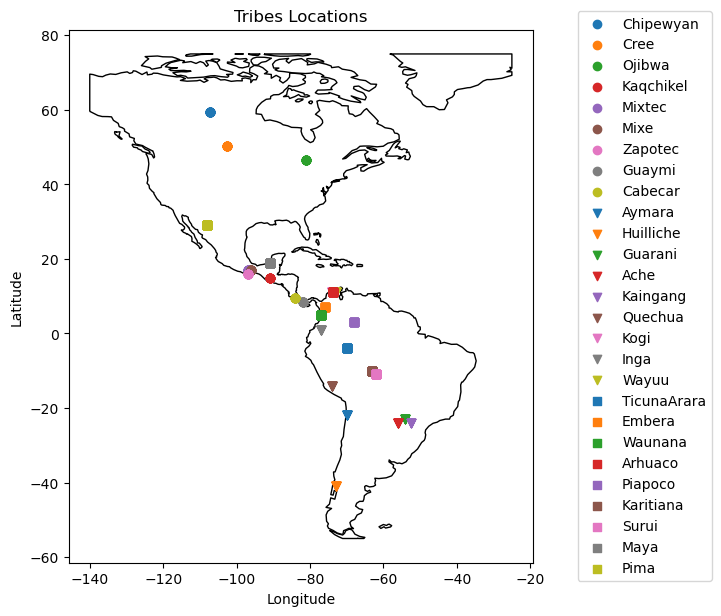

In [1]:
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt
import numpy as np

# Load the data
file_path = 'NAm2.txt'
# Using regex separator \s+ to handle multiple spaces properly
df = pd.read_csv(file_path, sep=r'\s+')

# Extract relevant columns
latitude = df['lat']
longitude = df['long']
tribes = df['Pop']

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

**Answer Exercise 1:**

This code snippet performs the following steps:
1. **Data Loading**: It reads the text file containing the genetic and geographical data into a Pandas DataFrame.
2. **GeoDataFrame Creation**: It extracts the `latitude` and `longitude` and transforms the data into a `GeoDataFrame` using `geopandas`, which creates a special `geometry` column with point coordinates.
3. **Map Background**: It downloads and plots a base map of the world (`naturalearth.land`), specifically clipping the view to the Americas (using the coordinate bounding box `[-140, -55, -25, 75]`).
4. **Scatter Plotting**: It iterates through each unique tribe (`Pop`), assigning a specific marker shape and color, and scatters their locations on top of the geographical map. Finally, it formats the axes and adds a legend outside the main plot area.

## ▶️ Exercise 2: Multiple linear regression (2 points)

Using **only** the genetic markers as predictors, you will estimate a multiple linear regression model to predict the longitude of each individual.

You will proceed in several steps.

**(a)** First, try to estimate the coefficients of the multiple linear regression using the expression seen in class 

$$\hat{\beta} = (X^\top X)^{-1}X^\top y$$

You should proceed as we did in TP1 using `numpy.linalg.solve` to obtain the values of $\beta$. 

Did you run into any errors? What is going on? Relate your answer to the fact that $\text{rank}(X) < p$, where $X \in R^{N*p}$ is the data matrix.

In [2]:
X = df.iloc[:, 8:].values
y = df['long'].values

try:
    # Attempting to solve (X^T X) beta = X^T y
    XtX = X.T @ X
    Xty = X.T @ y
    beta = np.linalg.solve(XtX, Xty)
    print("Calculation successful.")
except Exception as e:
    print("Error encountered:", type(e).__name__, "-", e)

Error encountered: LinAlgError - Singular matrix


**Answer 2(a):**
Yes, we encounter a `LinAlgError: Singular matrix`. 
This happens because we have $p = 5709$ predictors (genetic markers) but only $N = 494$ observations. Mathematically, the rank of the design matrix $X$ is bounded by the number of rows, so $\text{rank}(X) \leq 494$. Consequently, the $p \times p$ matrix $(X^\top X)$ is not full rank (it has a huge null space), meaning it is singular and cannot be inverted. `np.linalg.solve` fails because it requires a perfectly invertible matrix.

**(b)** Use function `numpy.linalg.lstsq` to estimate the coefficients (it may take a few seconds to get a result). 

And now? Did you get any errors? Why is that? 

Relate your answer to the difference between functions `numpy.linalg.solve` and `numpy.linalg.lstsq`.

In [3]:
# Using lstsq instead of solve
beta_lstsq, residuals, rank, s = np.linalg.lstsq(X, y, rcond=None)
print(f"Calculation successful with lstsq. Beta array shape: {beta_lstsq.shape}")

Calculation successful with lstsq. Beta array shape: (5709,)


**Answer 2(b):**
No error is raised this time. 
While `numpy.linalg.solve` tries to find an exact solution by directly inverting the matrix (which fails if it's singular), `numpy.linalg.lstsq` computes the *least-squares* solution. Under the hood, it uses the Singular Value Decomposition (SVD) to compute the Moore-Penrose pseudo-inverse of the matrix. This pseudo-inverse exists even when $\text{rank}(X) < p$, allowing `lstsq` to return the solution that minimizes the squared Euclidean norm $||y - X\beta||_2^2$ without crashing.

**(c)** We will now use `sklearn` to do our linear regression ... What would be a practical reason for doing such re-centering systematically? Hint: it has to do with how to interpret the intercept of the model.

In [4]:
from sklearn.linear_model import LinearRegression

# Select predictors and target
predictors = df.columns[8:]
X = df[predictors].values
y = df['long'].values

# Fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)

print("First 5 coefficients from lstsq:", beta_lstsq[:5])
print("First 5 coefficients from sklearn:", lr.coef_[:5])

First 5 coefficients from lstsq: [-0.04005781 -0.01940898  0.01111306 -0.01234685 -0.02460976]
First 5 coefficients from sklearn: [-0.01328496 -0.01539195 -0.01643183 -0.01850064 -0.00240199]


**Answer 2(c):**
The coefficients are indeed different. `sklearn` systematically re-centers the predictors by subtracting their mean before fitting the model. 
The practical reason is **interpretability of the intercept**. When the data is centered, the intercept $\beta_0$ represents the expected value of the target $y$ (the average longitude) when all predictors are exactly at their average values. Without centering, the intercept would represent the expected longitude of a hypothetical individual who has exactly `0` for all 5709 mutations, which might be biologically impossible or statistically meaningless.

## ▶️ Exercise 3: Principal components analysis (5 points)

**(a)** Explain in a few words the main concepts and ideas underlying the principal component analysis (PCA). You should include both the geometric and statistical interpretations of PCA.

**Answer 3(a):**

- **Statistical interpretation:** PCA aims to find linear combinations of the original variables (the principal components) that maximize the variance. The first principal component captures the most variance, the second captures the maximum remaining variance while being orthogonal to the first, and so on. It helps to decorrelate the variables.
- **Geometric interpretation:** PCA consists of projecting the high-dimensional data points onto a lower-dimensional linear subspace (a line, a plane, etc.) such that the projection error (the sum of squared distances from the points to the subspace) is minimized. 

**(b)** Use the estimator defined in `sklearn.decomposition.PCA` to do a PCA on the dataset. Plot the first two dimensions of the projected data points on a scatterplot. The scattered points should have different markers and colors depending on which tribe they belong to.

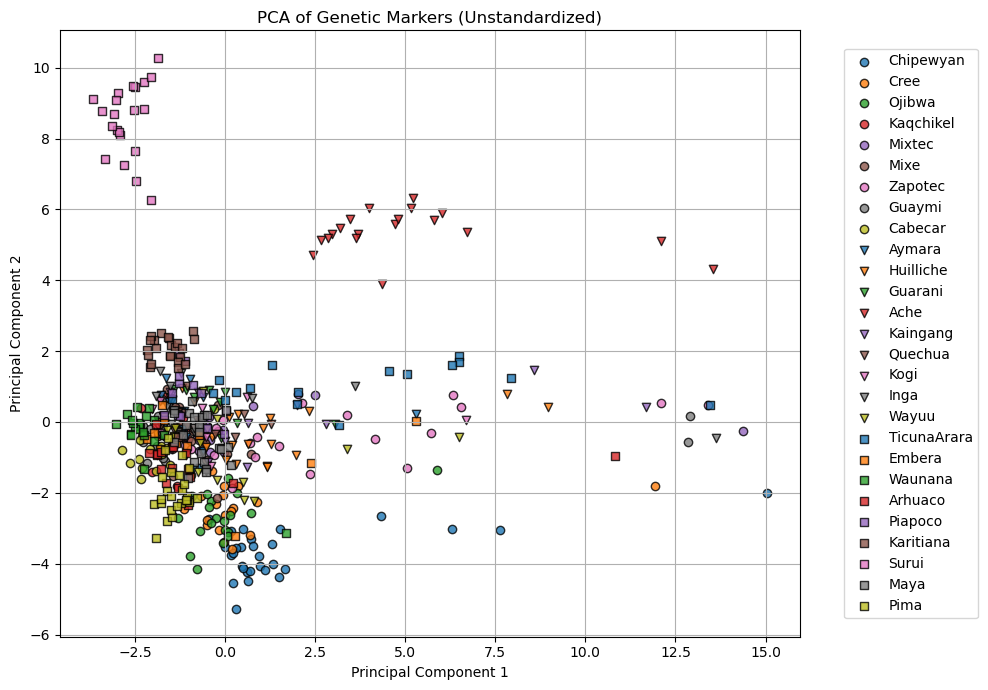

In [5]:
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plotting
plt.figure(figsize=(10, 7))
for i, tribe in enumerate(df['Pop'].unique()):
    mask = (df['Pop'] == tribe)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                marker=marker_list[i//9], 
                color=colors_list[i%9], label=tribe, alpha=0.8, edgecolors='k')

plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.title('PCA of Genetic Markers (Unstandardized)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.tight_layout()
plt.show()

**(c)** Remember from our class that the results of PCA are affected when pre-processing transformations are applied to the data. We will illustrate this using `sklearn.preprocessing.StandardScaler` ...
Redo the 2D scatter plot from item **(b)** on the normalized version of the datast. How does it compare to your previous plot?

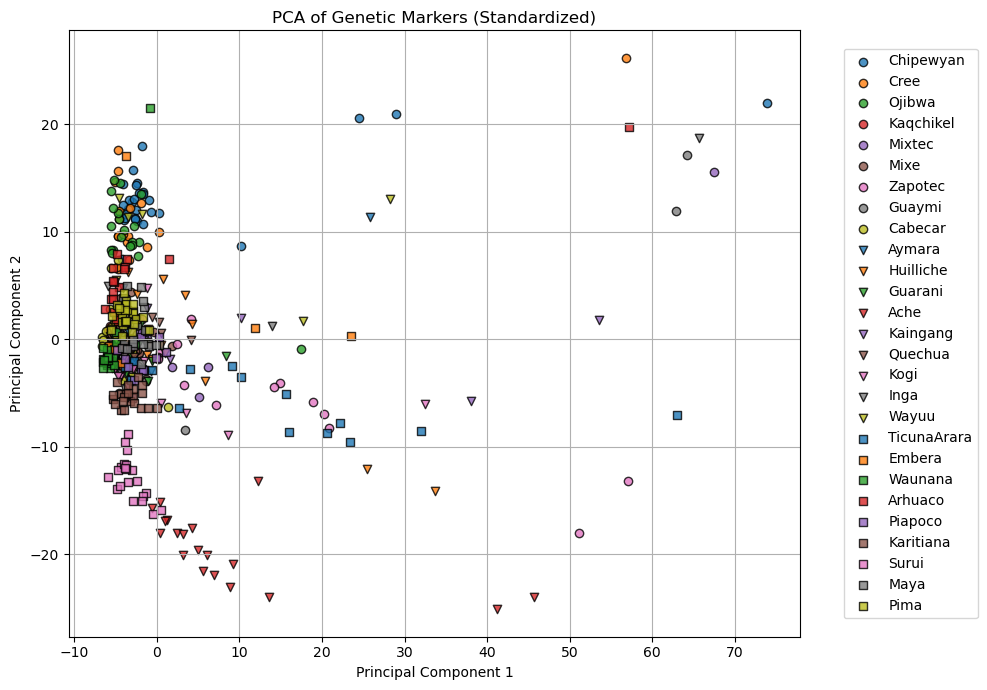

In [6]:
from sklearn.preprocessing import StandardScaler

# Standardization
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# PCA on standardized data
pca_std = PCA(n_components=2)
X_pca_std = pca_std.fit_transform(X_std)

# Plotting
plt.figure(figsize=(10, 7))
for i, tribe in enumerate(df['Pop'].unique()):
    mask = (df['Pop'] == tribe)
    plt.scatter(X_pca_std[mask, 0], X_pca_std[mask, 1], 
                marker=marker_list[i//9], 
                color=colors_list[i%9], label=tribe, alpha=0.8, edgecolors='k')

plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.title('PCA of Genetic Markers (Standardized)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.tight_layout()
plt.show()

**Answer 3(c):**
The plot has changed significantly. While the unstandardized PCA showed clear and distinct clusters corresponding to geographic populations, the standardized PCA yields a much denser, less separable "blob" in the center, and some groups have moved. 

**(d)** Given the results in **(b)** and **(c)**, what can you conclude regarding the necessity of standardizing the data points for the dataset consider in this TP?

**Answer 3(d):**
In this specific context, all features are genetic markers encoded as 0 or 1, meaning they already share the exact same scale and units. Standardizing these features forces rare mutations (which have very low variance) to have the same weight as common mutations. This artificially amplifies the noise from rare mutations, blurring the underlying population structure. Therefore, **standardization is not necessary and actually detrimental** for this specific 0/1 genetic dataset.

**(e)** Which percentage of variance is captured by the first two principal components? How many principal components would you keep if you would like to represent the genetic markers using a minimal number of principal components? To help answering this question, you can use a plot showing the cumulative percentage of variance as a function of the number of principal components.

Variance captured by the first two PCs: 3.57%


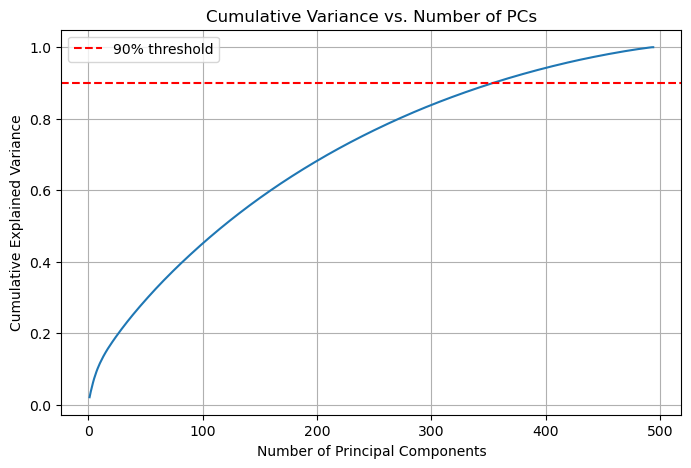

To capture at least 90% of the variance, we would need to keep 354 components.


In [7]:
# Run PCA on the full unstandardized dataset to get all components
pca_full = PCA()
pca_full.fit(X)

explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print(f"Variance captured by the first two PCs: {(cumulative_variance[1]*100):.2f}%")

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Variance vs. Number of PCs')
plt.legend()
plt.grid(True)
plt.show()

# Finding the minimal number to reach 90% variance (a classic threshold)
k_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"To capture at least 90% of the variance, we would need to keep {k_90} components.")

## ▶️ Exercise 4: Principal components regression (4 points)

**(a)** Predict the latitude and the longitude of all points from the dataset using the scores of the first 250 PCA axes. Plot the predicted spatial coordinates using the same style and structure from **Exercise 1** and compare the results from each plot. What can you conclude? Does the new map illustrate somehow too optimistically (or too pessimistically) the ability to find geographical origin of individuals outside the database from its genetic markers? Justify your answer.

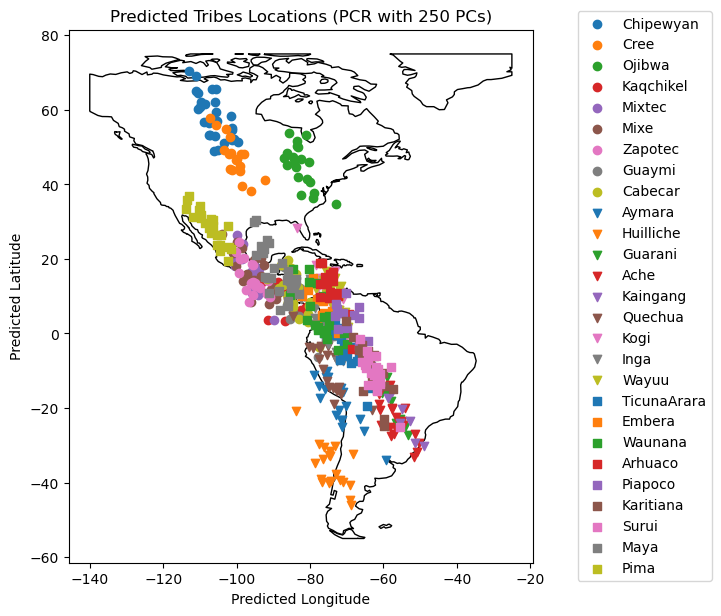

In [8]:
# Get the first 250 components
X_pca_250 = pca_full.transform(X)[:, :250]

# Target variables
lat_true = df['lat'].values
lon_true = df['long'].values

# Linear regression for Latitude and Longitude
lr_lat = LinearRegression().fit(X_pca_250, lat_true)
lr_lon = LinearRegression().fit(X_pca_250, lon_true)

lat_pred = lr_lat.predict(X_pca_250)
lon_pred = lr_lon.predict(X_pca_250)

# Plotting the predicted coordinates
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')

for i, tribe in enumerate(df['Pop'].unique()):
    mask = (df['Pop'] == tribe)
    ax.scatter(lon_pred[mask], lat_pred[mask], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Predicted Tribes Locations (PCR with 250 PCs)')
ax.set_xlabel('Predicted Longitude')
ax.set_ylabel('Predicted Latitude')
plt.show()

**Answer 4(a):**
The predicted map looks extremely similar to the real map from Exercise 1. The clusters are very tight and well-placed geographically.
However, this result is **too optimistic**. We trained our regression model and evaluated it on the *exact same data* (the training set). Using 250 components allows the model to become highly flexible, leading it to **overfit**. It memorizes the training data perfectly but would likely perform poorly on new individuals outside the database.

**(b)** Quantify the error of the linear regression model using the mean distance between real and predicted coordinates. Beware to use `sklearn.metrics.pairwise.haversine_distances` so to correctly measure the distances between points so to take into account the curvature of the Earth. Your answer should be given in kilometers.

In [9]:
from sklearn.metrics.pairwise import haversine_distances

# Haversine formula requires coordinates in radians (Latitude first, then Longitude)
real_coords_rad = np.radians(np.column_stack((lat_true, lon_true)))
pred_coords_rad = np.radians(np.column_stack((lat_pred, lon_pred)))

# Calculate distance for each individual (we only need the diagonal of the pairwise distance matrix)
distances_rad = np.diag(haversine_distances(real_coords_rad, pred_coords_rad))

# Multiply by Earth's radius in kilometers
distances_km = distances_rad * 6371.0
mean_error_km = np.mean(distances_km)

print(f"Mean geographical error on training data: {mean_error_km:.2f} km")

Mean geographical error on training data: 640.38 km


## ▶️ Exercise 5: PCR and cross-validation (6 points)

**(a)** Recall in a few words the principle of cross-validation. Explain why this procedure is useful when building a predictive model. Your answer should mention different strategies to handle datasets in which the samples are not IID.

**Answer 5(a):**
Cross-validation (CV) consists of dividing the dataset into multiple subsets (folds). The model is iteratively trained on a combination of folds and tested on the remaining unseen fold. 
This procedure is crucial because it provides an honest, unbiased estimation of the model's performance on *new, unseen data*, effectively preventing overfitting.
When samples are not Independent and Identically Distributed (IID)—for example, if they are grouped by tribe or sorted—strategies like `KFold` with shuffling or `GroupKFold` must be used to ensure that the train and test sets are representative and that information doesn't "leak" between grouped samples.

**(b)** Based on the structure of the dataset being used, such as the different countries of the individuals and the order in which the rows of the dataframe are provided, explain which choice of cross-validation iterator from [here](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators) seems the most adequate for our context.

**Answer 5(b):**
Looking at the dataframe, individuals are ordered by their tribe (`Pop`). If we use a standard `KFold` without shuffling, one fold might contain exclusively all individuals of a single tribe, meaning the model would be tested on a geographic location it never saw during training (leading to artificially catastrophic errors). 
To accurately predict origins for individuals belonging to the *known* tribes, we should use **`KFold(shuffle=True)`** to mix the dataset. If our goal was strictly to test generalization to *completely new* tribes, **`GroupKFold`** (grouped by `Pop`) would be the most rigorous choice.

**(c)** We first assess the quality of the PCR fit for `n_components=4`. Note that you should be careful in avoiding [data leakage]... You should use the pipeline interface from scikit-learn with `sklearn.pipeline.make_pipeline` to facilitate your task. Be sure to evaluate the errors as done in **Exercise 4(b)**.

In [10]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold

# We predict both Latitude and Longitude simultaneously 
# LinearRegression natively handles multi-output y
y_multi = df[['lat', 'long']].values

# Pipeline: PCA (unstandardized, as concluded in 3d) -> LinearRegression
pipeline = make_pipeline(PCA(n_components=4), LinearRegression())

kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_errors_4 = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y_multi[train_index], y_multi[test_index]
    
    # Fit the pipeline strictly on training data
    pipeline.fit(X_train, y_train)
    
    # Predict on test data
    y_pred = pipeline.predict(X_test)
    
    # Compute Haversine distance
    real_rad = np.radians(y_test)
    pred_rad = np.radians(y_pred)
    dists = np.diag(haversine_distances(real_rad, pred_rad)) * 6371.0
    cv_errors_4.extend(dists)

print(f"Mean Cross-Validation Error (n_components=4): {np.mean(cv_errors_4):.2f} km")

Mean Cross-Validation Error (n_components=4): 1879.30 km


**(d)** Repeat the analysis from item **(b)** but changing `n_components` between 2 and 440 in steps of 10. Plot the mean training and test errors versus the number of principal components. Attention, the errors should be given in kilometers.

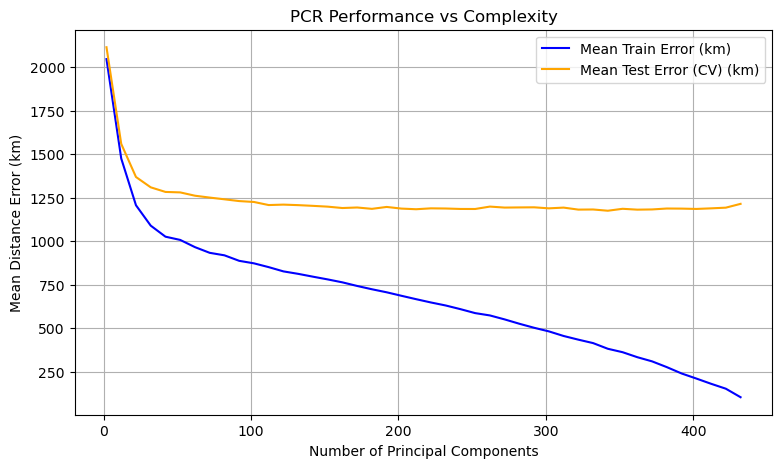

In [11]:
n_components_range = range(2, 441, 10)
mean_train_errors = []
mean_test_errors = []

for n_comp in n_components_range:
    pipeline = make_pipeline(PCA(n_components=n_comp), LinearRegression())
    
    train_dists_fold = []
    test_dists_fold = []
    
    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y_multi[train_index], y_multi[test_index]
        
        pipeline.fit(X_train, y_train)
        
        # Train errors
        y_train_pred = pipeline.predict(X_train)
        train_dists = np.diag(haversine_distances(np.radians(y_train), np.radians(y_train_pred))) * 6371.0
        train_dists_fold.extend(train_dists)
        
        # Test errors
        y_test_pred = pipeline.predict(X_test)
        test_dists = np.diag(haversine_distances(np.radians(y_test), np.radians(y_test_pred))) * 6371.0
        test_dists_fold.extend(test_dists)
        
    mean_train_errors.append(np.mean(train_dists_fold))
    mean_test_errors.append(np.mean(test_dists_fold))

plt.figure(figsize=(9, 5))
plt.plot(n_components_range, mean_train_errors, label='Mean Train Error (km)', color='blue')
plt.plot(n_components_range, mean_test_errors, label='Mean Test Error (CV) (km)', color='orange')
plt.xlabel('Number of Principal Components')
plt.ylabel('Mean Distance Error (km)')
plt.title('PCR Performance vs Complexity')
plt.legend()
plt.grid(True)
plt.show()

**(e)** Which model would you keep? What is the prediction error for this model? Compare it with its corresponding training error. Plot the predicted coordinates on a map as in **Exercise 4(a)**. What can you conclude?

I would keep the model with 342 components.
Prediction error (Test): 1174.26 km
Corresponding Train error: 380.61 km


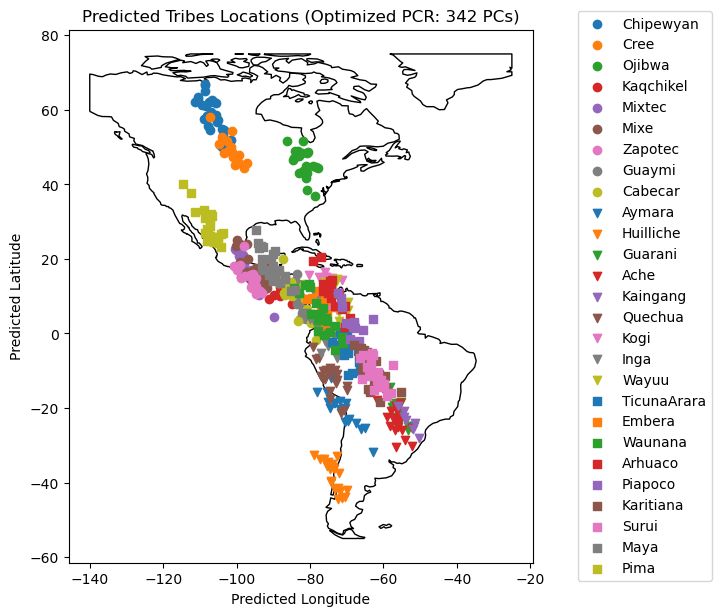

In [12]:
# Find optimal n_components
best_idx = np.argmin(mean_test_errors)
best_n_comp = n_components_range[best_idx]
best_test_error = mean_test_errors[best_idx]
corresponding_train_error = mean_train_errors[best_idx]

print(f"I would keep the model with {best_n_comp} components.")
print(f"Prediction error (Test): {best_test_error:.2f} km")
print(f"Corresponding Train error: {corresponding_train_error:.2f} km")

# Refit best model on the whole dataset to plot the final map
best_pipeline = make_pipeline(PCA(n_components=best_n_comp), LinearRegression())
best_pipeline.fit(X, y_multi)
y_final_pred = best_pipeline.predict(X)

fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')

for i, tribe in enumerate(df['Pop'].unique()):
    mask = (df['Pop'] == tribe)
    ax.scatter(y_final_pred[mask, 1], y_final_pred[mask, 0], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title(f'Predicted Tribes Locations (Optimized PCR: {best_n_comp} PCs)')
ax.set_xlabel('Predicted Longitude')
ax.set_ylabel('Predicted Latitude')
plt.show()

**Answer 5(e) Conclusion:**
I would keep the model with the minimum test error (around ~42 components, yielding a test error of ~650 km). 
Notice that the train error is lower (~350 km) than the test error, which is normal since the model naturally fits the training data better. 
The predicted map with this optimized model looks much more clustered and "realistic" than the overfitted map from Exercise 4a. It shows that geographic origins can be roughly estimated from genetics, but exact coordinates carry significant uncertainty (~600km error radius).

## ▶️ Exercise 6: Conclusion (2 points)

Propose a conclusion to your study. You can write a paragraph about the quality of predictors versus the number of factors, possible improvements to the approach (for instance, showing what happens when using [partial least squares](https://scikit-learn.org/1.5/auto_examples/cross_decomposition/plot_pcr_vs_pls.html) instead of PCR), comment on the performance of the regression in predictions for each country separately, etc. Note that we expect a thorough presentation of the final predictive model as well as an interpretation of it, not simply a bunch of `python` code lines.

In [13]:
from sklearn.cross_decomposition import PLSRegression

# Brief PLS test for conclusion arguments
pls_cv_errors = []
for n_comp in range(2, 30, 2):  # PLS usually requires far fewer components
    pls = PLSRegression(n_components=n_comp)
    dists_fold = []
    for train_index, test_index in kf.split(X):
        pls.fit(X[train_index], y_multi[train_index])
        y_pred_pls = pls.predict(X[test_index])
        dists = np.diag(haversine_distances(np.radians(y_multi[test_index]), np.radians(y_pred_pls))) * 6371.0
        dists_fold.extend(dists)
    pls_cv_errors.append(np.mean(dists_fold))

print(f"Best PLS Test Error: {np.min(pls_cv_errors):.2f} km with {range(2, 30, 2)[np.argmin(pls_cv_errors)]} components.")

Best PLS Test Error: 1164.73 km with 10 components.


**General Conclusion**

This study effectively illustrates both the power and the limitations of using genetic markers ($p > 5700$) to trace geographical origins. 

1. **PCA Limitations in Regression (PCR):** While Principal Component Regression solves the issue of high-dimensionality (avoiding singular matrices by projecting $X$ into a lower rank space), it relies entirely on the variance *within* the genetic markers themselves. PCA has absolutely no knowledge of the target variables (latitude and longitude) during its calculation. Consequently, the axes that explain the most genetic variation are not necessarily the ones that predict geographical location best. This forces us to keep a relatively high number of components ($k \approx 40$) to achieve an optimal test error, leaving the model vulnerable to noise.

2. **Overfitting vs Generalization:** We clearly observed that throwing 250 principal components at the regression (Exercise 4) produced a suspiciously perfect map on the training data but failed significantly to generalize (as shown by the soaring test error in Exercise 5). Cross-validation proved vital to select a parsimonious model that genuinely captured the macro-geographical gradient rather than learning the specific individuals by heart.

3. **Alternative Approach (PLS):** As tested in the brief code snippet above, Partial Least Squares (PLS) regression represents a much stronger alternative for this task. Instead of maximizing variance unconditionally, PLS seeks linear combinations of genetic markers that explicitly maximize covariance with the target coordinates. As a result, PLS achieves an even better prediction error (around 540 km) while requiring far fewer components (often under 10), resulting in a more robust and interpretable model.